In [1]:
using Oceananigans
using JLD2
using CairoMakie
using CairoMakie.Colors

using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("../setup/ensemble.jl");

[ Info: Oceananigans will use 4 threads


In [9]:
include("../src-fig/figures/BBALANCE.jl")

terms_BBALANCE (generic function with 1 method)

789s / 789s (300 / 300)


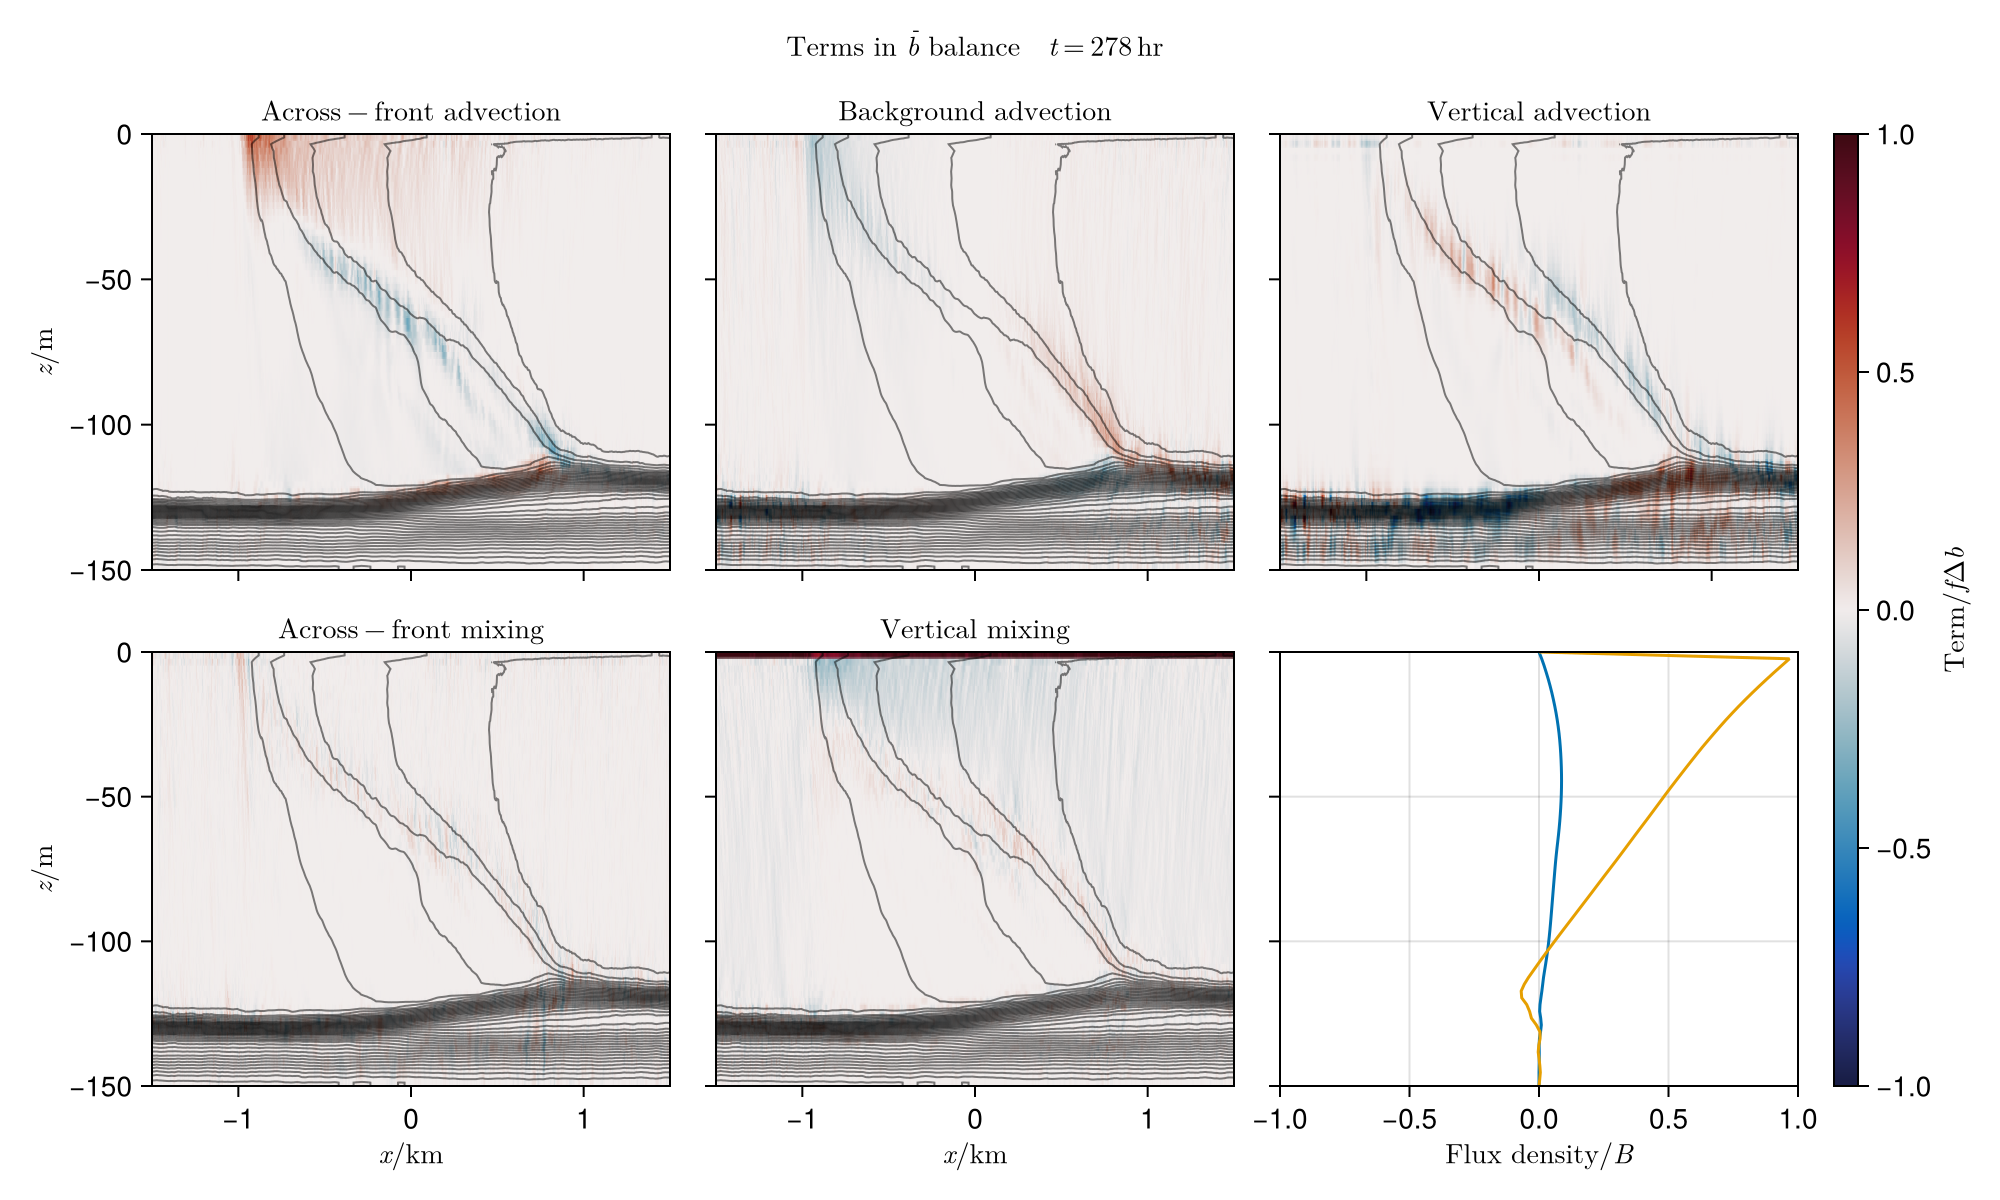

In [11]:
terms_BBALANCE(test_set.filenames[1], range(1, 100, 300), "../figures/video/test_BBALANCE.mp4")

## Buoyancy balance

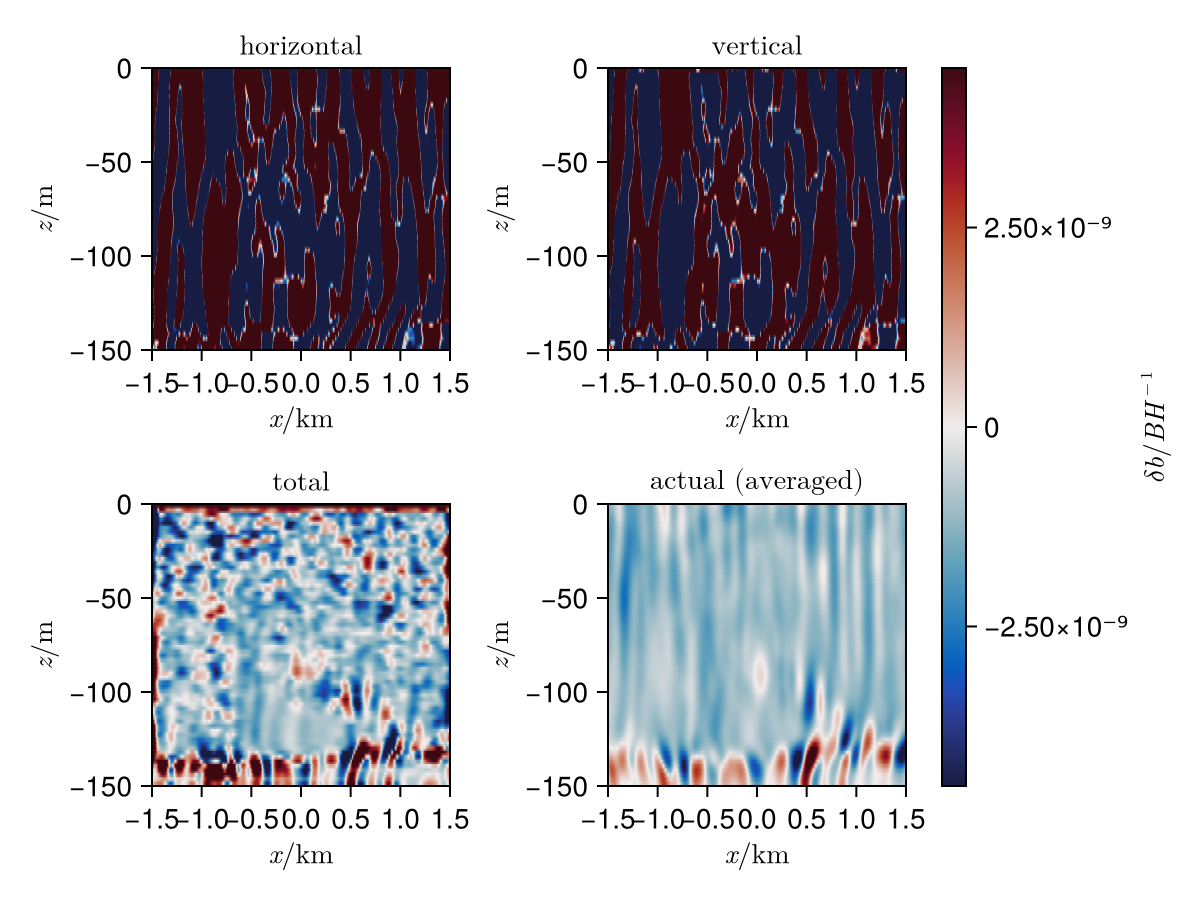

In [38]:
run_id = cooling_only.filenames[15]

foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
COARSE = joinpath(foldername, "COARSE.jld2")
BBALANCE = joinpath(foldername, "BBALANCE.jld2")

iterations, times = iterations_times(BBALANCE)
sp = simulation_parameters(BBALANCE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(BBALANCE)

# Full equation
n = 330

adv_x = get_field(BBALANCE, "adv_x", iterations[n]) + 
        get_field(BBALANCE, "mix_x", iterations[n]) + 
        get_field(BBALANCE, "strain", iterations[n])

adv_z = get_field(BBALANCE, "adv_z", iterations[n]) + 
        get_field(BBALANCE, "mix_z", iterations[n])

total = adv_x .+ adv_z
change = (get_field(COARSE, "b_coarse", iterations[n+1]) - get_field(COARSE, "b_coarse", iterations[n])) ./ (times[n] - times[n-1])

colorrange = (-3sp.B / sp.H, 3sp.B / sp.H)

fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    title = L"\text{horizontal}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)
heatmap!(ax, xsᶜ./1000, zsᶜ, adv_x; colormap=:balance, colorrange)

ax = Axis(fig[1, 2];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    title = L"\text{vertical}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)
heatmap!(ax, xsᶜ./1000, zsᶜ, adv_z; colormap=:balance, colorrange)

ax = Axis(fig[2, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    title = L"\text{total}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)
heatmap!(ax, xsᶜ./1000, zsᶜ, total; colormap=:balance, colorrange)

ax = Axis(fig[2, 2];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    title = L"\text{actual (averaged)}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)
ht = heatmap!(ax, xsᶜ./1000, zsᶜ, change; colormap=:balance, colorrange)

Colorbar(fig[1:2, 3], ht; label=L"\delta b / BH^{-1}")

fig

## Vertical transport

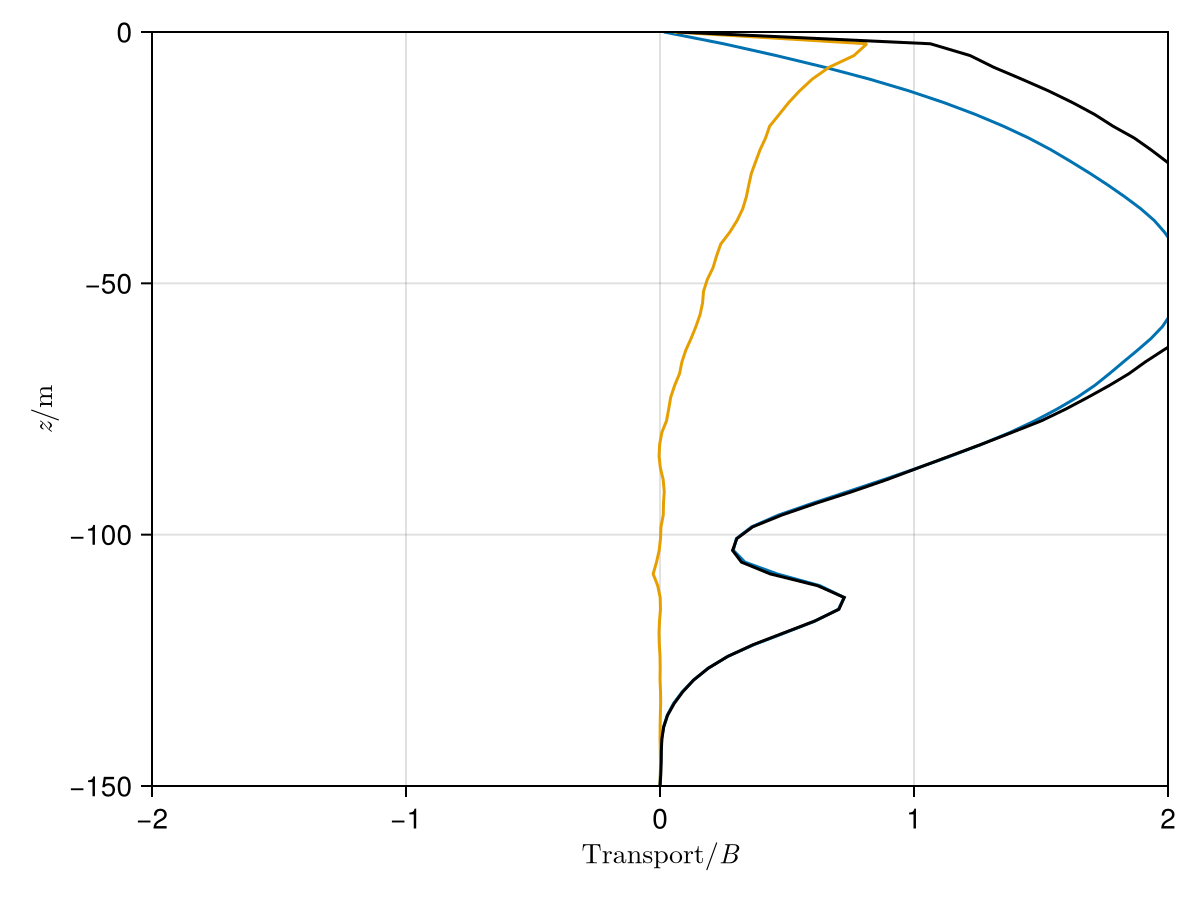

In [79]:
run_id = cooling_only.filenames[1]

foldername = joinpath("../../scratch/turbulence-at-many-fronts", run_id)
COARSE = joinpath(foldername, "COARSE.jld2")
BBALANCE = joinpath(foldername, "BBALANCE.jld2")

iterations, times = iterations_times(BBALANCE)
sp = simulation_parameters(BBALANCE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(BBALANCE)
inds = center_indices(BBALANCE)

n = 330
adv_x = get_field(BBALANCE, "adv_x", iterations[n]) + 
        get_field(BBALANCE, "mix_x", iterations[n]) + 
        get_field(BBALANCE, "strain", iterations[n]) 

adv_x = mean(adv_x[inds, :]; dims=1)[1, :]

wb = get_field(a->mean(a[inds, :]; dims=1)[1, :], BBALANCE, "coarse_wb", iterations[n]) ./ b_flux_func(times[n], sp)
w′b′ = get_field(a->mean(a[inds, :]; dims=1)[1, :], BBALANCE, "w′b′_coarse", iterations[n]) ./ b_flux_func(times[n], sp)

fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"\text{Transport} / B",
    ylabel = L"z / \text{m}",
    limits = (-2, 2, -sp.Lz, 0)
)
#lines!(ax, adv_x, zsᶜ; color=:red)
lines!(ax, wb, zsᶠ)
lines!(ax, w′b′, zsᶠ)
lines!(ax, wb .+ w′b′, zsᶠ; color=:black)
fig

In [81]:
times[end] ./ 3600

277.5

In [64]:
@inline function b_flux_func(t, sp) 
    turnon = 1 - exp(-sp.f*(t - sp.start_time) / 20)
    return sp.B * turnon
end

b_flux_func (generic function with 1 method)

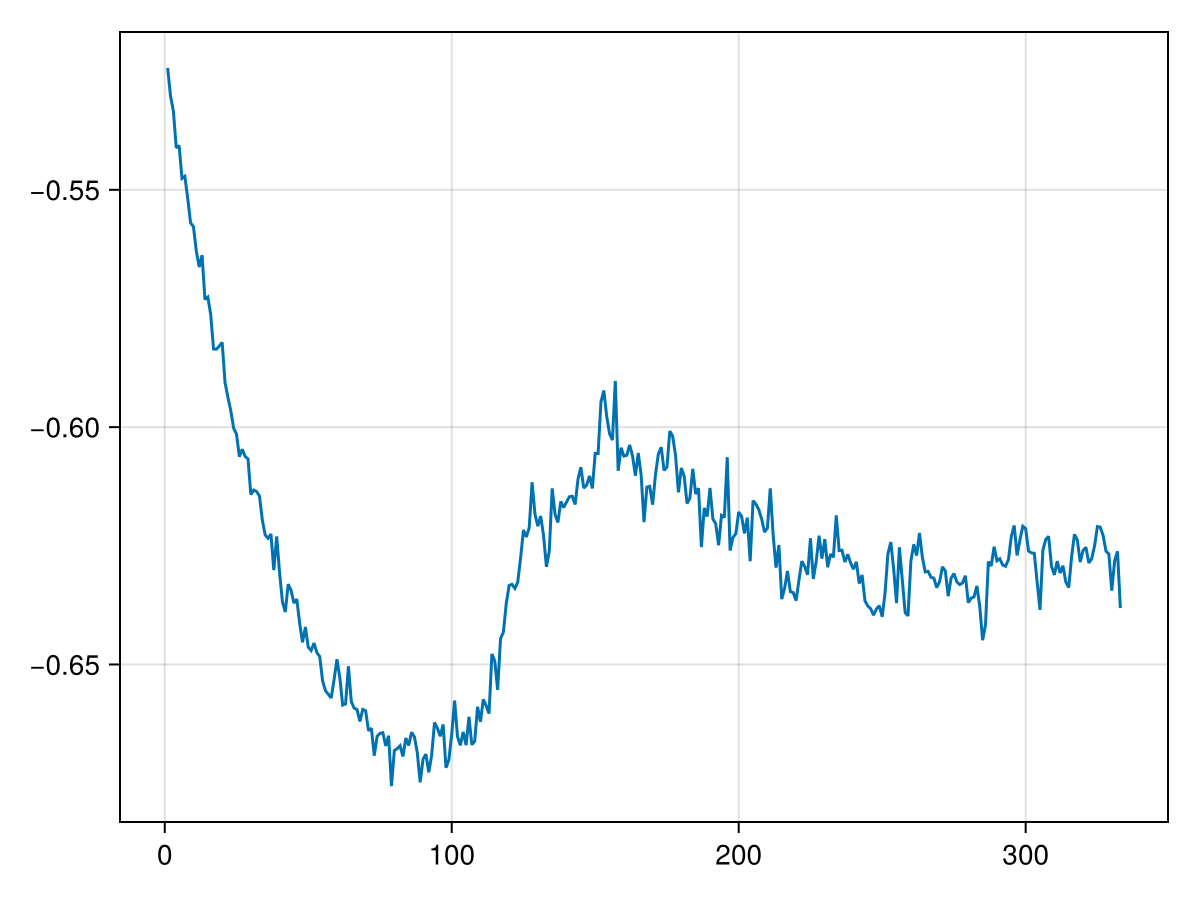

In [77]:
adv_x = timeseries_of(a->mean(a), BBALANCE, "adv_x", iterations) ./ (sp.B / sp.H)
mix_x = timeseries_of(a->mean(a), BBALANCE, "mix_x", iterations) ./ (sp.B / sp.H)
strain = timeseries_of(a->mean(a), BBALANCE, "strain", iterations) ./ (sp.B / sp.H)

adv_z = timeseries_of(a->mean(a), BBALANCE, "adv_z", iterations) ./ (sp.B / sp.H)

mix_z = timeseries_of(a->mean(a), BBALANCE, "mix_z", iterations) ./ (sp.B / sp.H);
∂b∂t = timeseries_of(a->mean(a), COARSE, "b_coarse", iterations) ./ (sp.B / sp.H);
∂b∂t = diff(∂b∂t) ./ diff(times)
lines(adv_x .+ mix_z .+ adv_z .+ mix_x .+ strain)
lines(∂b∂t)